In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

(b) Normalized 5×5 ∂G/∂x (Frobenius norm = 1):
[[ 0.191108  0.13903  -0.       -0.13903  -0.191108]
 [ 0.278061  0.202288 -0.       -0.202288 -0.278061]
 [ 0.315084  0.229222 -0.       -0.229222 -0.315084]
 [ 0.278061  0.202288 -0.       -0.202288 -0.278061]
 [ 0.191108  0.13903  -0.       -0.13903  -0.191108]]
sum: 0.0
(b) Normalized 5×5 ∂G/∂y:
[[ 0.191108  0.278061  0.315084  0.278061  0.191108]
 [ 0.13903   0.202288  0.229222  0.202288  0.13903 ]
 [-0.       -0.       -0.       -0.       -0.      ]
 [-0.13903  -0.202288 -0.229222 -0.202288 -0.13903 ]
 [-0.191108 -0.278061 -0.315084 -0.278061 -0.191108]]
sum: -2.7755575615628914e-17


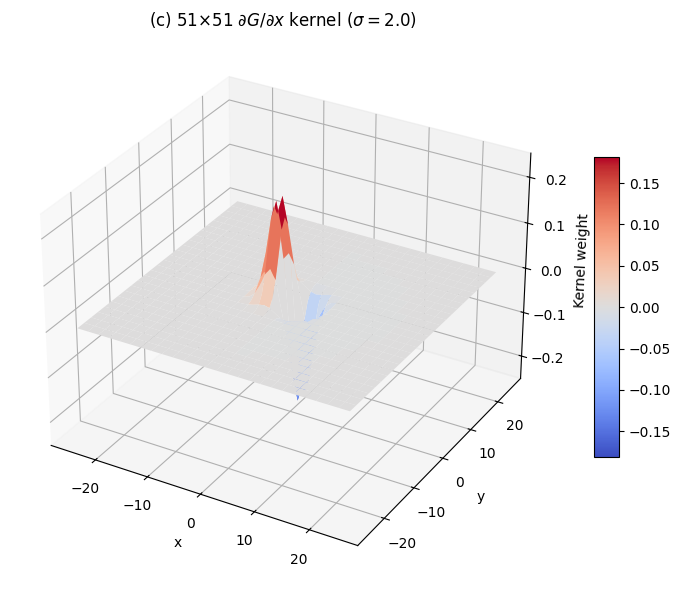

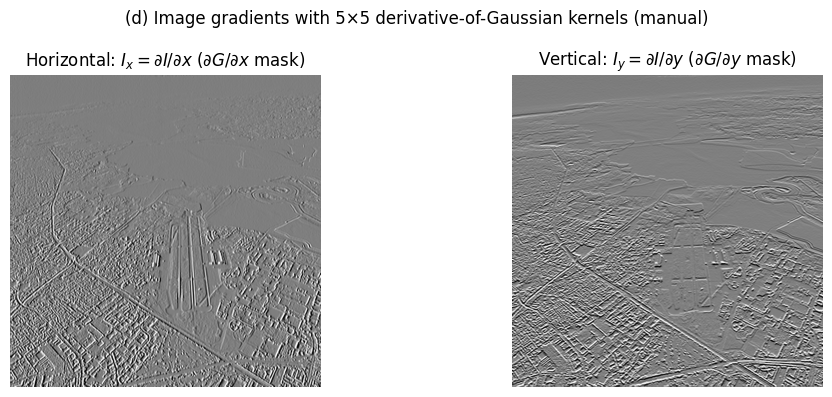

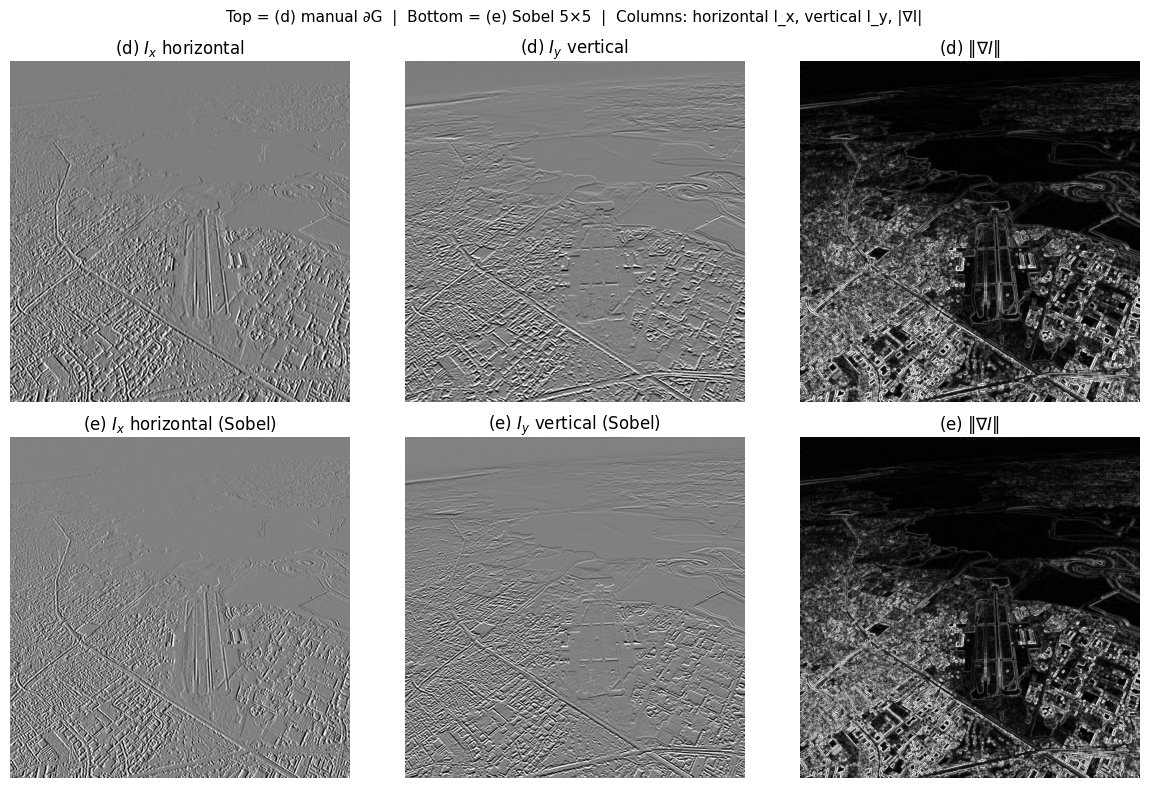

Pearson(Ix manual, Ix Sobel): -0.9561
Pearson(Iy manual, Iy Sobel): -0.9634


In [2]:
SIGMA = 2.0


def gaussian_analytic(xx: np.ndarray, yy: np.ndarray, sigma: float) -> np.ndarray:
    return (1.0 / (2.0 * np.pi * sigma * sigma)) * np.exp(
        -(xx * xx + yy * yy) / (2.0 * sigma * sigma)
    )


def derivative_of_gaussian_kernels(size: int, sigma: float):
    """Sample ∂G/∂x and ∂G/∂y; return Frobenius-normalized kernels."""
    if size % 2 == 0:
        raise ValueError("size must be odd")
    r = size // 2
    ax = np.arange(-r, r + 1, dtype=np.float64)
    xx, yy = np.meshgrid(ax, ax)
    G = gaussian_analytic(xx, yy, sigma)
    Gx = -(xx / (sigma * sigma)) * G
    Gy = -(yy / (sigma * sigma)) * G
    Gx /= np.sqrt(np.sum(Gx * Gx))
    Gy /= np.sqrt(np.sum(Gy * Gy))
    return Gx, Gy


# --- (b) 5×5 kernels ---
Gx5, Gy5 = derivative_of_gaussian_kernels(5, SIGMA)
np.set_printoptions(precision=6, suppress=True)
print("(b) Normalized 5×5 ∂G/∂x (Frobenius norm = 1):")
print(Gx5)
print("sum:", Gx5.sum())
print("(b) Normalized 5×5 ∂G/∂y:")
print(Gy5)
print("sum:", Gy5.sum())

# --- (c) 51×51 ∂G/∂x surface ---
Gx51, _ = derivative_of_gaussian_kernels(51, SIGMA)
r = 25
x = np.arange(-r, r + 1, dtype=np.float64)
X, Y = np.meshgrid(x, x)

fig = plt.figure(figsize=(8, 6))
ax3 = fig.add_subplot(111, projection="3d")
surf = ax3.plot_surface(X, Y, Gx51, cmap="coolwarm", linewidth=0, antialiased=True)
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("Kernel weight")
ax3.set_title(rf"(c) 51×51 $\partial G/\partial x$ kernel ($\sigma={SIGMA}$)")
fig.colorbar(surf, shrink=0.55, aspect=12)
plt.tight_layout()
plt.show()

# --- (d)(e) image gradients on runaway.png ---
path = "images/runaway.png"
bgr = cv2.imread(path)
if bgr is None:
    raise FileNotFoundError(path)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float64)

Ix_man = cv2.filter2D(gray, ddepth=-1, kernel=Gx5, borderType=cv2.BORDER_REFLECT)
Iy_man = cv2.filter2D(gray, ddepth=-1, kernel=Gy5, borderType=cv2.BORDER_REFLECT)

Ix_sob = cv2.Sobel(gray, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=5)
Iy_sob = cv2.Sobel(gray, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=5)


def grad_mag(Ix, Iy):
    return np.sqrt(Ix * Ix + Iy * Iy)


def norm01(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a, dtype=np.float64)
    lo, hi = np.percentile(a, 1), np.percentile(a, 99)
    return np.clip((a - lo) / (hi - lo + 1e-9), 0, 1)


# Figure A — part (d) only: horizontal vs vertical (manual kernels)
fig_a, ax_a = plt.subplots(1, 2, figsize=(11, 4))
fig_a.suptitle(
    "(d) Image gradients with 5×5 derivative-of-Gaussian kernels (manual)",
    fontsize=12,
)
ax_a[0].imshow(norm01(Ix_man), cmap="gray")
ax_a[0].set_title(r"Horizontal: $I_x = \partial I/\partial x$ ($\partial G/\partial x$ mask)")
ax_a[1].imshow(norm01(Iy_man), cmap="gray")
ax_a[1].set_title(r"Vertical: $I_y = \partial I/\partial y$ ($\partial G/\partial y$ mask)")
for ax in ax_a:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Figure B — (d) vs (e): manual top row, Sobel bottom row
fig_b, axes = plt.subplots(2, 3, figsize=(12, 8))
fig_b.suptitle(
    "Top = (d) manual ∂G  |  Bottom = (e) Sobel 5×5  |  Columns: horizontal I_x, vertical I_y, |∇I|",
    fontsize=11,
)
axes[0, 0].imshow(norm01(Ix_man), cmap="gray")
axes[0, 0].set_title(r"(d) $I_x$ horizontal")
axes[0, 1].imshow(norm01(Iy_man), cmap="gray")
axes[0, 1].set_title(r"(d) $I_y$ vertical")
axes[0, 2].imshow(norm01(grad_mag(Ix_man, Iy_man)), cmap="gray")
axes[0, 2].set_title(r"(d) $\|\nabla I\|$")
axes[1, 0].imshow(norm01(Ix_sob), cmap="gray")
axes[1, 0].set_title(r"(e) $I_x$ horizontal (Sobel)")
axes[1, 1].imshow(norm01(Iy_sob), cmap="gray")
axes[1, 1].set_title(r"(e) $I_y$ vertical (Sobel)")
axes[1, 2].imshow(norm01(grad_mag(Ix_sob, Iy_sob)), cmap="gray")
axes[1, 2].set_title(r"(e) $\|\nabla I\|$")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()


def pearson(a, b):
    a, b = a.ravel(), b.ravel()
    a, b = a - a.mean(), b - b.mean()
    return float((a * b).sum() / (np.sqrt((a * a).sum() * (b * b).sum()) + 1e-12))


print(f"Pearson(Ix manual, Ix Sobel): {pearson(Ix_man, Ix_sob):.4f}")
print(f"Pearson(Iy manual, Iy Sobel): {pearson(Iy_man, Iy_sob):.4f}")